# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [10]:
# Add code here 🔧
#3.
len(df)

1000

In [11]:
#4.
df['Liked'].mean() * 100

np.float64(50.0)

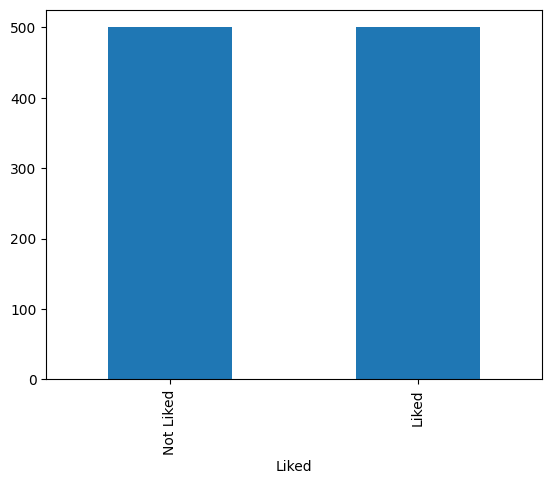

In [12]:
#5.
df['Liked'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.xticks([0,1], ['Not Liked', 'Liked'])
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [13]:
# Add code here 🔧
import re

# lowercase
df['Review'] = df['Review'].str.lower()

# remove URLs
df['Review'] = df['Review'].apply(lambda x: re.sub(r'http\S+', '', x))

# remove punctuation and non-letters/numbers
df['Review'] = df['Review'].apply(lambda x: re.sub(r'[^a-z0-9\s]', '', x))

### ✍️ Your Response: 🔧
1. If you include the junk in your model it would confuse it and add noise overall. This reduces the models accuracy and makes it much harder to identify real patterns in the reviews.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [18]:
# Add code here 🔧
#Installing the library and analyzer
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [19]:
#calculating the percentage of each
analyzer = SentimentIntensityAnalyzer()

# get sentiment scores
df['score'] = df['Review'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# convert to labels
def sentiment_label(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['score'].apply(sentiment_label)

# turn into percentages
df['sentiment'].value_counts(normalize=True) * 100

,proportion
sentiment,
positive,50.6
negative,25.5
neutral,23.9


### ✍️ Your Response: 🔧
1. When comparing the sentiment analysis to the liked analysis, we can clearly see that the sentiment version is much more detialed and shows that 50.6% positive, 25.5% negative, and 23.9% neutral which gives us a better understanding of customer opinions. In contrast, the like version only showed 50% positive and negative.

2. I would argue that negative reviews are the most important because they show problems that they are having and areas for improvment. This can help the owner understand what they can do to increase business in a positve way.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [20]:
# Add code here 🔧
#Import the NLTK library
import nltk

In [23]:
#Download the NLTK corpora
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [24]:
#Preprocess the text
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

df['processed'] = df['Review'].apply(preprocess)

In [25]:
#Display the first 10 processed reviews
df['processed'].head(10)

,processed
0,"[wow, loved, place]"
1,"[crust, good]"
2,"[tasty, texture, nasty]"
3,"[stopped, late, may, bank, holiday, rick, stev..."
4,"[selection, menu, great, price]"
5,"[getting, angry, want, damn, pho]"
6,"[honeslty, didnt, taste, fresh]"
7,"[potato, like, rubber, could, tell, made, ahea..."
8,"[fry, great]"
9,"[great, touch]"


### ✍️ Your Response: 🔧
1. Corpora is a collection of text information or data that is used in NLP which provides resource in an effort to help process text. For example, it has resources like stopwords.

2. The first review's token would be "['wow', 'loved', 'place']"

3. Lemmatization helps to reduce the words to their basic form to help group more similar words together and improve accuracy of analysiing text.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [27]:
# Add code here 🔧
#Import Dictionary and Corpus from the Genism library
!pip install gensim
from gensim.corpora import Dictionary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.9 MB/s eta 0:00:00


In [28]:
#Making a dictionary
dictionary = Dictionary(df['processed'])

In [29]:
#making a corpus
corpus = [dictionary.doc2bow(text) for text in df['processed']]

In [30]:
#Display a summary of the dictionary and corpus
print("Number of unique words:", len(dictionary))
print("First 5 entries in corpus:", corpus[:5])

Number of unique words: 1839
First 5 entries in corpus: [[(0, 1), (1, 1), (2, 1)], [(3, 1), (4, 1)], [(5, 1), (6, 1), (7, 1)], [(0, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1)], [(16, 1), (17, 1), (18, 1), (19, 1)]]


### ✍️ Your Response: 🔧
1. A corpus is a bunch of text documents that is converted into numbers and show us how often a word appears in the dataset which helps models analyze patterns and find topics.

2. In contrast, a dictionary is something that maps each word to a unique ID and then uses that to show how many time it is in a document or dataset.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [31]:
# Add code here 🔧
from gensim.models import LdaModel

In [32]:
#Select the number of topics
num_topics = 5

In [33]:
#Create the LDA model
lda_model = LdaModel(corpus=corpus, id2word=dictionary,num_topics=num_topics)

### ✍️ Your Response: 🔧
1. You might use more than 5 topics when the data has a lot of different themes or info. For example, for reviews it may discuss multiple things like price or location and so more topics may be neccesary to capture the full picture and be accurate.

2. You know if you have to many topics when they begin to overlap with one another or are hard to understant as a topic must be clear and meaningful to add value.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


In [35]:
# Add code here 🔧
#Print the topics and top 10 words in the topic
lda_model.print_topics(num_words=10)

[(0,
  '0.021*"good" + 0.016*"food" + 0.013*"place" + 0.011*"service" + 0.010*"time" + 0.010*"really" + 0.008*"star" + 0.008*"nice" + 0.007*"go" + 0.006*"like"'),
 (1,
  '0.016*"place" + 0.016*"good" + 0.010*"dont" + 0.009*"service" + 0.009*"made" + 0.007*"experience" + 0.007*"also" + 0.007*"time" + 0.006*"well" + 0.006*"ever"'),
 (2,
  '0.032*"food" + 0.020*"great" + 0.019*"place" + 0.015*"back" + 0.011*"go" + 0.011*"service" + 0.009*"best" + 0.009*"restaurant" + 0.007*"good" + 0.006*"delicious"'),
 (3,
  '0.019*"good" + 0.016*"service" + 0.015*"food" + 0.012*"back" + 0.012*"great" + 0.011*"place" + 0.010*"amazing" + 0.009*"like" + 0.007*"pretty" + 0.006*"came"'),
 (4,
  '0.014*"place" + 0.013*"time" + 0.010*"service" + 0.009*"food" + 0.007*"going" + 0.007*"eat" + 0.006*"one" + 0.006*"like" + 0.006*"really" + 0.006*"worst"')]

In [36]:
#Calculate the frequency
topic_counts = {}

for doc in corpus:
    topic = max(lda_model.get_document_topics(doc), key=lambda x: x[1])[0]
    topic_counts[topic] = topic_counts.get(topic, 0) + 1

topic_counts

{2: 302, 3: 193, 0: 198, 1: 163, 4: 144}

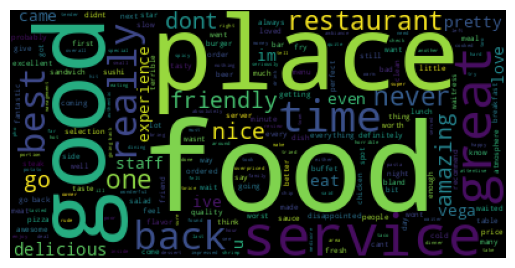

In [38]:
#Word cloud creation
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join([' '.join(review) for review in df['processed']])

wordcloud = WordCloud().generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [42]:
#sentiment by topic
df['topic'] = [max(lda_model.get_document_topics(doc), key=lambda x: x[1])[0] for doc in corpus]

In [43]:
pd.crosstab(df['topic'], df['sentiment'], normalize='index') * 100

sentiment,negative,neutral,positive
topic,,,
0,26.530612,25.000000,48.469388
1,29.012346,22.839506,48.148148
2,21.122112,29.372937,49.504950
3,22.959184,17.346939,59.693878
4,32.867133,20.979021,46.153846


### ✍️ Your Response: 🔧
List your topics and names here:

Topic #0 General Thoughts

Topic #1 Customer Complaints

Topic #2 Food Quality

Topic #3 Great Service

Topic #4 Mixed Reviews

## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. The model helped to answer and find out what customers are saying in their reviews the most and if their experiences were generally more positive or not.

2. For this restaurant I would recommend focusing on improving the service for customers as that was a common pain point and also make sure to maintian food quality and not cut corners as that aided in positive reviews.

3. The pros is that it is much faster and easier to use as you can understand the context better with little to no coding. The con is you have less control over the model which means less consistent results.

4. I would ask it the following:"analyze these restaurant reviews by identifying the main topics discussed and classify each review as postive negative or neutral. Then summarize the main themes and give recommendations for the business with the goal of improve customer satisfation."

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [9]:
!jupyter nbconvert --to html "assignment_13_text_analytics.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_13_text_analytics.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tr